# Resultados QSVM en relación con SVM-RBF de sklearn

El análisis compara dos grupos QSVM con la referencia clásica del notebook `SVM_RBF.ipynb`:

- **Mayor expresividad:** combinaciones con mayor promedio de todos los valores del heatmap, incluida la diagonal.
- **Mayor accuracy:** combinaciones con mayor exactitud en prueba.
- **SVM-RBF sklearn:** pipeline clásico con imputación, estandarización, SMOTE y `GridSearchCV`, resumido sobre las semillas 42, 123 y 2026.

La referencia clásica utiliza las 3276 observaciones y las QSVM usan subconjuntos pequeños. Por tanto, la gráfica da contexto frente a sklearn, pero no representa una comparación controlada uno-a-uno.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display

from qsvm_experiment_analysis import QSVMExperimentAnalysis


def encontrar_raiz_repo():
    actual = Path.cwd().resolve()
    for candidato in (actual, *actual.parents):
        if (candidato / "data" / "water_potability.csv").exists():
            return candidato
    raise FileNotFoundError("No se encontró la raíz del repositorio.")


REPO_ROOT = encontrar_raiz_repo()
IMG_DIR = REPO_ROOT / "img"
analisis = QSVMExperimentAnalysis(REPO_ROOT, IMG_DIR, random_seed=42)

## Configuración

In [2]:
TOP_K = 3

COMBINACIONES = [
    {"N": 64, "dim": 5, "featuremap": "z_feature_map"},
    {"N": 48, "dim": 4, "featuremap": "zz_feature_map"},
    {"N": 48, "dim": 4, "featuremap": "custom_q_kernel"},
    {"N": 48, "dim": 6, "featuremap": "pauli_feature_map"},
    {"N": 24, "dim": 2, "featuremap": "pauli_feature_map"},
    {"N": 16, "dim": 2, "featuremap": "zz_feature_map"},
    {"N": 40, "dim": 2, "featuremap": "custom_q_kernel"},
    {"N": 72, "dim": 2, "featuremap": "z_feature_map"},
    {"N": 64, "dim": 2, "featuremap": "efficient_su2"},
]

COMBINACION_H2 = {"N": 40, "dim": 3, "featuremap": "efficient_su2"}

display(pd.DataFrame(COMBINACIONES))

,N,dim,featuremap
0,64,5,z_feature_map
1,48,4,zz_feature_map
2,48,4,custom_q_kernel
3,48,6,pauli_feature_map
4,24,2,pauli_feature_map
5,16,2,zz_feature_map
6,40,2,custom_q_kernel
7,72,2,z_feature_map
8,64,2,efficient_su2


## Generación unificada

Procesando n_64_dim_5_z_feature_map
Procesando n_48_dim_4_zz_feature_map
Procesando n_48_dim_4_custom_q_kernel
Procesando n_48_dim_6_pauli_feature_map
Procesando n_24_dim_2_pauli_feature_map
Procesando n_16_dim_2_zz_feature_map
Procesando n_40_dim_2_custom_q_kernel
Procesando n_72_dim_2_z_feature_map
Procesando n_64_dim_2_efficient_su2

Imagen: grupo_mayor_expresividad_metricas_vs_sklearn


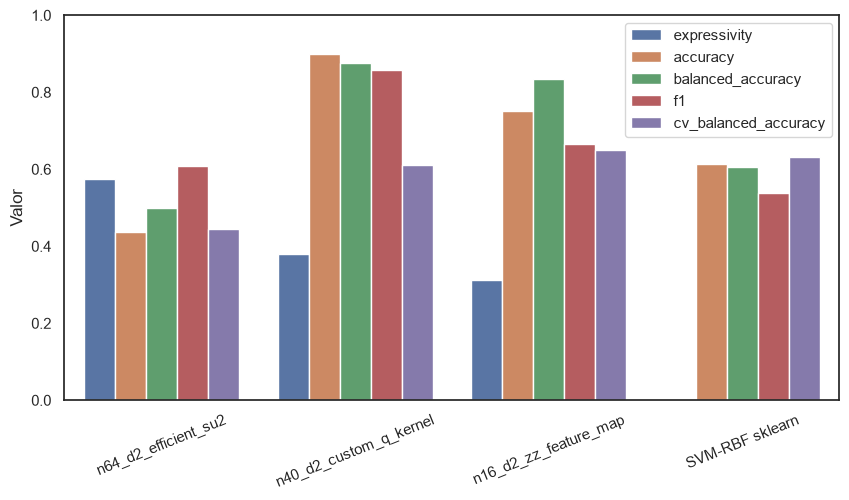


Imagen: grupo_mayor_accuracy_metricas_vs_sklearn


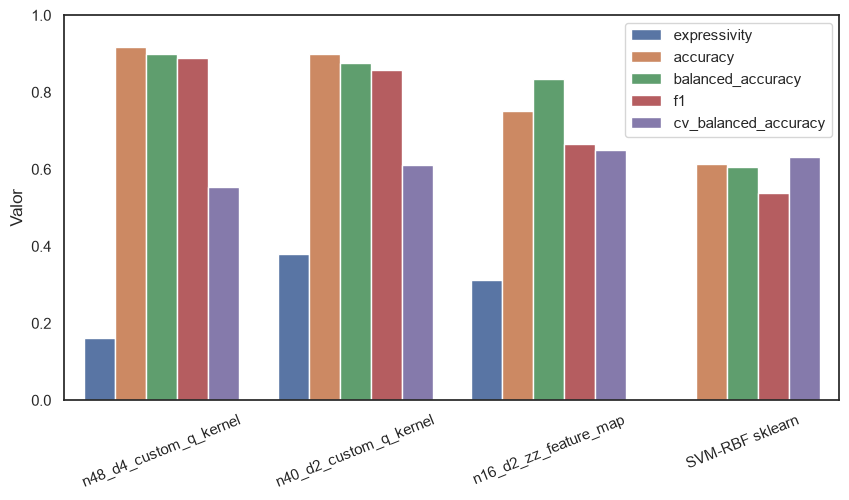


Imagen: grupo_mayor_expresividad_heatmaps_escala_0_1


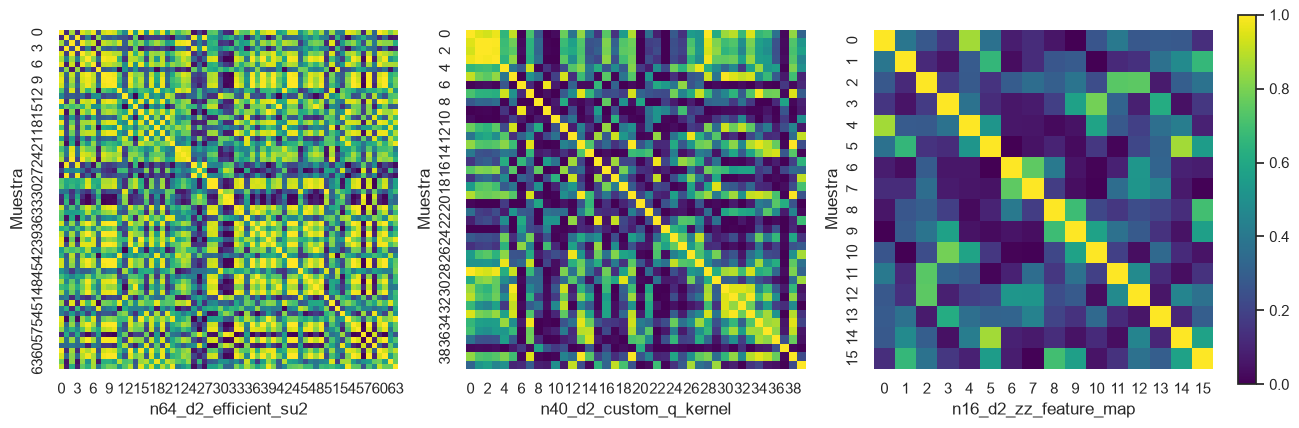


Imagen: grupo_mayor_accuracy_heatmaps_escala_0_1


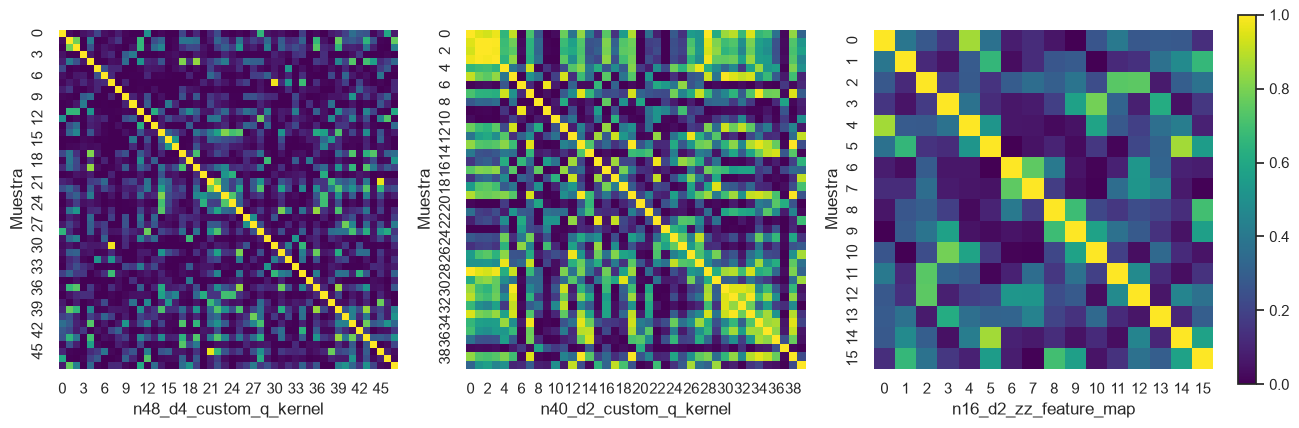


Imagen: grupo_mayor_expresividad_profundidad_compuertas_2q


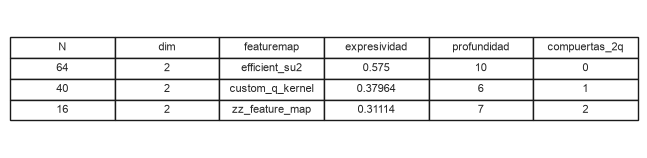


Imagen: n_64_dim_2_efficient_su2_circuito


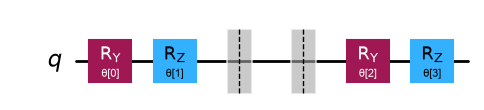


Imagen: n_64_dim_2_efficient_su2_circuito_transpilado


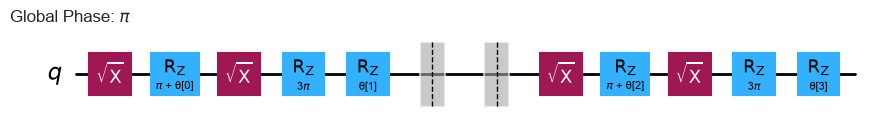


Imagen: n_40_dim_2_custom_q_kernel_circuito


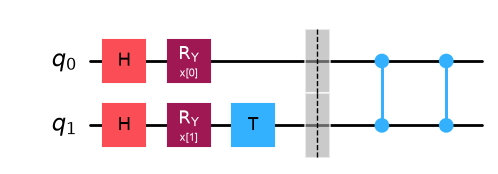


Imagen: n_40_dim_2_custom_q_kernel_circuito_transpilado


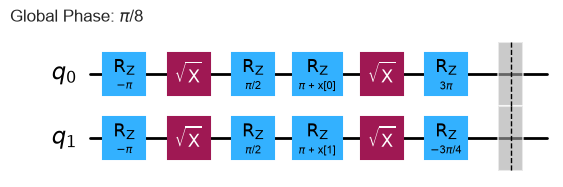


Imagen: n_16_dim_2_zz_feature_map_circuito


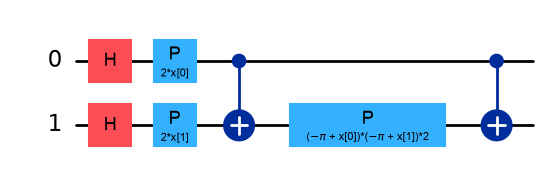


Imagen: n_16_dim_2_zz_feature_map_circuito_transpilado


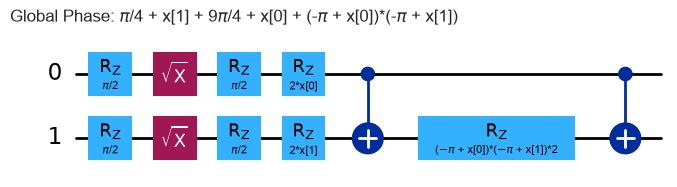


Imagen: n_40_dim_3_efficient_su2_entrenamiento_kernel_h2_ruido_absoluto


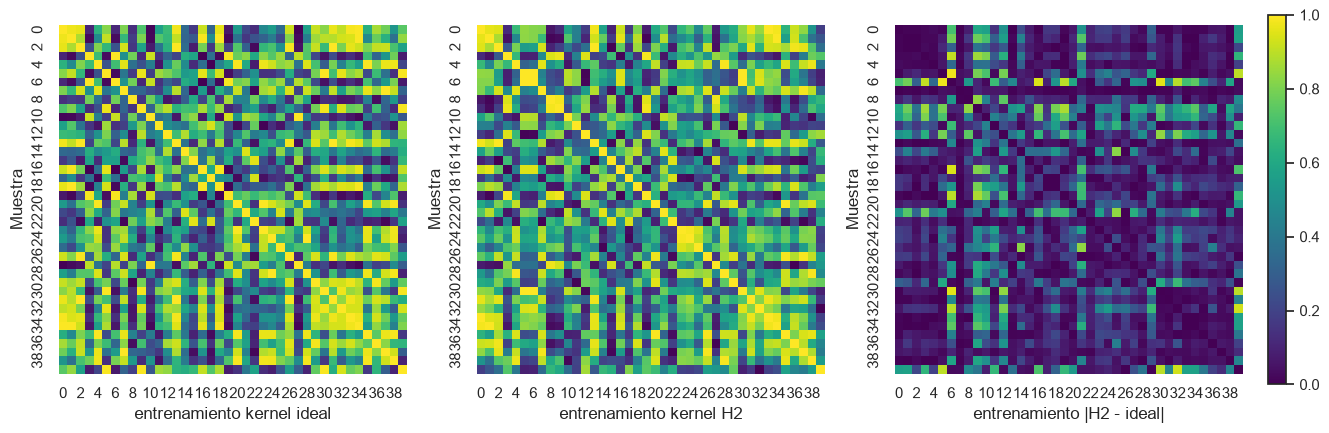


Imagen: n_40_dim_3_efficient_su2_prueba_kernel_h2_ruido_absoluto


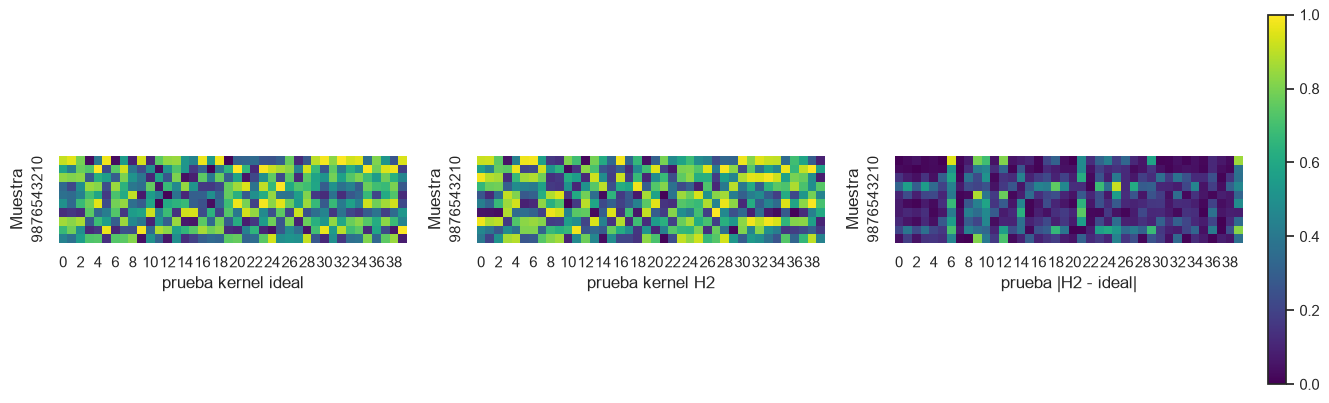

Grupo QSVM de mayor expresividad


,N,dim,featuremap,expressivity,accuracy,balanced_accuracy,f1,cv_balanced_accuracy,circuit_depth,two_qubit_gates
0,64,2,efficient_su2,0.575002,0.4375,0.500000,0.608696,0.445238,10,0
1,40,2,custom_q_kernel,0.379644,0.9000,0.875000,0.857143,0.611667,6,1
2,16,2,zz_feature_map,0.311137,0.7500,0.833333,0.666667,0.650000,7,2


Grupo QSVM de mayor accuracy


,N,dim,featuremap,expressivity,accuracy,balanced_accuracy,f1,cv_balanced_accuracy,circuit_depth,two_qubit_gates
0,48,4,custom_q_kernel,0.160885,0.916667,0.900000,0.888889,0.555000,25,4
1,40,2,custom_q_kernel,0.379644,0.900000,0.875000,0.857143,0.611667,6,1
2,16,2,zz_feature_map,0.311137,0.750000,0.833333,0.666667,0.650000,7,2


Referencia clásica SVM-RBF sklearn: media de tres semillas


,N,dim,featuremap,expressivity,accuracy,accuracy_std,balanced_accuracy,balanced_accuracy_std,f1,f1_std,cv_balanced_accuracy,cv_balanced_accuracy_std,circuit_depth,two_qubit_gates
0,3276,9,SVM_RBF_sklearn,NaN,0.612297,0.00352,0.606146,0.008155,0.537288,0.019722,0.632444,0.007629,NaN,NaN


Comparación H2 y ruido absoluto generada.


In [3]:
(
    resultados,
    mayor_expresividad,
    mayor_accuracy,
    referencia_sklearn,
    faltantes_h2,
) = analisis.run_focused(COMBINACIONES, COMBINACION_H2, top_k=TOP_K)

print("Grupo QSVM de mayor expresividad")
display(mayor_expresividad)

print("Grupo QSVM de mayor accuracy")
display(mayor_accuracy)

print("Referencia clásica SVM-RBF sklearn: media de tres semillas")
display(referencia_sklearn)

if faltantes_h2:
    print("No se generó la comparación H2 porque faltan:")
    for archivo in faltantes_h2:
        print(f"  {archivo}")
else:
    print("Comparación H2 y ruido absoluto generada.")

## Interpretación de la referencia

Las barras `SVM-RBF sklearn` corresponden al promedio de las semillas 42, 123 y 2026. La validación cruzada clásica mostrada es la exactitud balanceada del mejor modelo seleccionado por F1 en cada semilla. La expresividad no aplica al modelo RBF clásico y por eso no se dibuja esa barra.

Las demás salidas permanecen enfocadas: heatmaps QSVM con escala común, tabla de profundidad y compuertas de dos qubits para el grupo expresivo, circuitos de ese grupo y ruido absoluto H2.